In [37]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from copy import deepcopy

from qibo.backends import construct_backend
from qibo import hamiltonians, Circuit, gates, set_backend
from qibo import gates, symbols
from qibo.gates import Unitary, CNOT, CZ
from qibo.symbols import X, Y, Z
from qibo import hamiltonians
from qibo.hamiltonians import Hamiltonian, SymbolicHamiltonian

from dbf_dbqa.group_commutator_iteration import GroupCommutatorIteration, DoubleBracketRotationApproximationType
from dbf_dbqa.utils_XXZ_compilation import *

In [38]:
L = 16
H_XXZ = XXZ_compilation_line(L,gateset="CNOT")

E0,E1 = H_XXZ.eigenergies_ED()
print(E0,E1)

-27.646948582300443 -26.769841716098966


In [39]:
init_circ, _, _ = H_XXZ.find_XXZ_HVA_circuit(nlayers=1)

Initial loss: -24.7651208337816
-26.93772471970199
   Normal return from subroutine COBYLA

   NFVALS =   17   F =-2.693772E+01    MAXCV = 0.000000E+00
   X = 2.221721E-01   1.218286E-01

[0.22217206 0.12182855]


## DBQA with Diagonal B-field (DBF)

In [40]:
B_i = [1]*L
dbf = hamiltonians.SymbolicHamiltonian(
    sum([ B_i[i] * Z(i) for i in range(L)]))

In [41]:
gci_hva = GroupCommutatorIteration(
    h=deepcopy(H_XXZ),
    preparation_circuit=init_circ,
    double_bracket_rotation_approximation_type=DoubleBracketRotationApproximationType.group_commutator_reduced)

In [42]:
from dbf_dbqa.utils_reporting import *
print_gate_count_report(init_circ)

Gate count report:
-------------------
Number of qubits: 16
Circuit depth: 17
Total gate count: 152
Gate counts:
  X: 16
  H: 8
  CNOT: 53
  RZ: 45
  RY: 30
Number of gates with generic Unitary type acting on exactly 1 qubit: 0
Number of gates acting on exactly 2 qubits: 53


--------------------------
Step 1
Step grid: [0.001  0.0045 0.008  0.0115 0.015  0.0185 0.022  0.0255 0.029  0.0325
 0.036  0.0395 0.043  0.0465 0.05  ]
Losses: [np.float64(-26.974092901977944), np.float64(-27.077730964147303), np.float64(-27.1530081470877), np.float64(-27.205355745908545), np.float64(-27.23821763241014), np.float64(-27.254059932302997), np.float64(-27.25472783103149), np.float64(-27.241634698002407), np.float64(-27.215880344472176), np.float64(-27.17833167742777), np.float64(-27.129680562117656), np.float64(-27.07048665118802), np.float64(-27.0012097220818), np.float64(-26.922234402565184), np.float64(-26.833889220979433)]
Optimal step: 0.022000000000000002
Minimum loss: -27.25472783103149


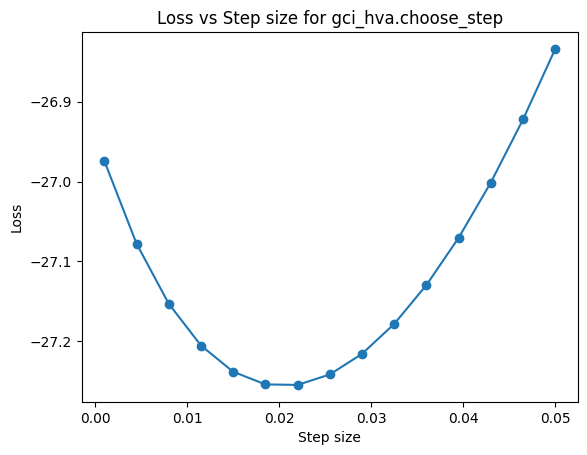

Circuit analysis after:
Gate count report:
-------------------
Number of qubits: 16
Circuit depth: 75
Total gate count: 696
Gate counts:
  Unitary: 64
  X: 48
  H: 24
  CNOT: 225
  RZ: 201
  RY: 134
Number of gates with generic Unitary type acting on exactly 1 qubit: 64
Number of gates acting on exactly 2 qubits: 225
--------------------------
Step 2
Step grid: [0.001  0.0045 0.008  0.0115 0.015  0.0185 0.022  0.0255 0.029  0.0325
 0.036  0.0395 0.043  0.0465 0.05  ]
Losses: [np.float64(-27.27735850387166), np.float64(-27.342615369584582), np.float64(-27.387248561904048), np.float64(-27.413653881993497), np.float64(-27.424203678558936), np.float64(-27.421048365061985), np.float64(-27.406082022714557), np.float64(-27.38094498883161), np.float64(-27.34703892901969), np.float64(-27.30554649937224), np.float64(-27.257452407042546), np.float64(-27.203564404514605), np.float64(-27.1445334974847), np.float64(-27.080873004836693), np.float64(-27.01297629658229)]
Optimal step: 0.015
Minimum los

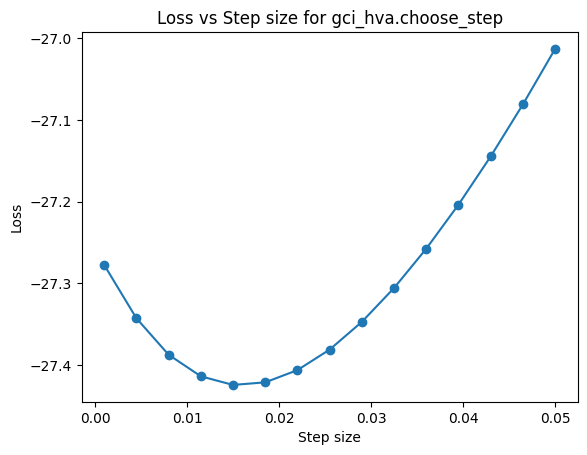

Circuit analysis after:
Gate count report:
-------------------
Number of qubits: 16
Circuit depth: 249
Total gate count: 2328
Gate counts:
  Unitary: 256
  X: 144
  H: 72
  CNOT: 741
  RZ: 669
  RY: 446
Number of gates with generic Unitary type acting on exactly 1 qubit: 256
Number of gates acting on exactly 2 qubits: 741
--------------------------
Step 3
Step grid: [0.001  0.0045 0.008  0.0115 0.015  0.0185 0.022  0.0255 0.029  0.0325
 0.036  0.0395 0.043  0.0465 0.05  ]
Losses: [np.float64(-27.435881637857207), np.float64(-27.468636344152113), np.float64(-27.489866745870017), np.float64(-27.501578449156842), np.float64(-27.505367687974022), np.float64(-27.50237591312002), np.float64(-27.493362582035843), np.float64(-27.4787849506257), np.float64(-27.45886903995686), np.float64(-27.433669227737003), np.float64(-27.403116993757788), np.float64(-27.367060129268154), np.float64(-27.325293837389598), np.float64(-27.277585057919502), np.float64(-27.223691193764243)]
Optimal step: 0.015
Min

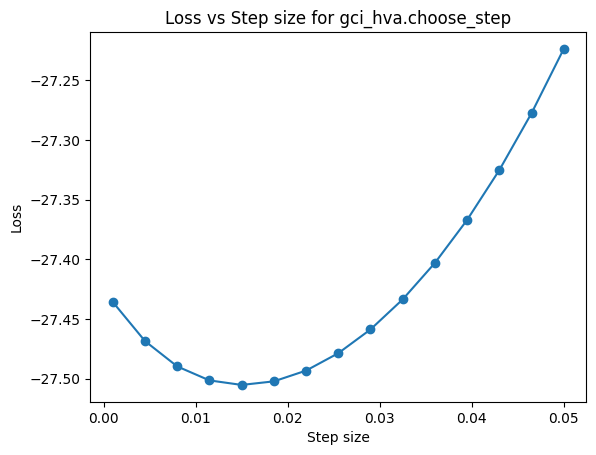

Circuit analysis after:
Gate count report:
-------------------
Number of qubits: 16
Circuit depth: 771
Total gate count: 7224
Gate counts:
  Unitary: 832
  X: 432
  H: 216
  CNOT: 2289
  RZ: 2073
  RY: 1382
Number of gates with generic Unitary type acting on exactly 1 qubit: 832
Number of gates acting on exactly 2 qubits: 2289
--------------------------
Step 4


In [ ]:
from collections import Counter
two_qubit_counter = lambda circ: sum(1 for gate in circ.queue if len(gate.qubits) == 2)

dbf_dbqa_two_qubit_counts = [ two_qubit_counter(init_circ) ]
dbf_dbqa_energies =  [ gci_hva.loss() ]
for step in range(5):
    print("--------------------------")
    print(f"Step {step+1}")   

    step_grid = np.linspace(0.001, 0.05, 15)
    s_opt, s_min, losses, _ = gci_hva.choose_step(
        dbf, step_grid=step_grid)
    print("Step grid:", step_grid)
    print("Losses:", losses)
    print(f"Optimal step: {s_opt}")
    print(f"Minimum loss: {s_min}")
    plt.figure()
    plt.plot(step_grid, losses, marker='o')
    plt.xlabel('Step size')
    plt.ylabel('Loss')
    plt.title('Loss vs Step size for gci_hva.choose_step')
    plt.show()
   
    gci_hva(s_opt, dbf)
    print("Circuit analysis after:")
    print_gate_count_report(gci_hva.preparation_circuit)  
    dbf_dbqa_two_qubit_counts.append( two_qubit_counter(gci_hva.preparation_circuit))
    dbf_dbqa_energies.append( gci_hva.loss() )    

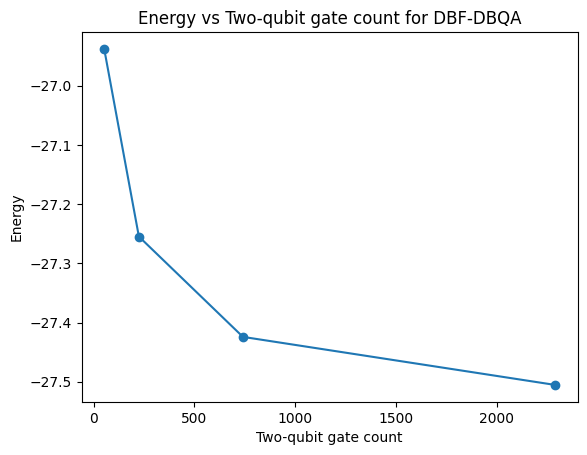

In [ ]:
plt.figure()
plt.plot(dbf_dbqa_two_qubit_counts, dbf_dbqa_energies, marker='o')
plt.xlabel('Two-qubit gate count')
plt.ylabel('Energy')
plt.title('Energy vs Two-qubit gate count for DBF-DBQA')
plt.show()

In [ ]:
import pickle

def load_data(filename):
    with open(filename+'.pickle', 'rb') as file:
        # Load the object from the file
        data = pickle.load(file)
    return data

def run_param_rc(fontsize = 30):
        import matplotlib.pyplot as plt
        plt.rcParams['axes.labelsize'] = fontsize
        plt.rcParams['axes.titlesize'] = fontsize
        plt.rcParams['font.size'] = fontsize
        #set_matplotlib_formats('pdf', 'png')
        plt.rcParams['savefig.dpi'] = 75
        plt.rcParams['lines.linewidth'] = 2.0
        plt.rcParams['lines.markersize'] = 8
        plt.rcParams['legend.fontsize'] = 12
        plt.rcParams['legend.labelspacing'] = .3
        plt.rcParams['legend.columnspacing']= .3
        plt.rcParams['legend.handletextpad']= .1
        plt.rcParams['text.usetex'] = True
        plt.rcParams['font.family'] = "serif"
        plt.rcParams['font.serif'] = "cm"

path = "../simulation_results/Qrisp_simulations_DB_QITE_and_QPE/data/benchmarks_2nd_L=16_05-21-18"
db_qite_simulation_results = load_data(path)
db_qite_energies = db_qite_simulation_results[1]['optimal_energies']
db_qite_cz_counts = [db_qite_simulation_results[0]['circuit_data'][0][i]['cz'] for i in range(len(db_qite_energies))]
print(db_qite_energies)

[np.float64(-26.971036078151435), np.float64(-27.387533684571018), np.float64(-27.516956618690205), np.float64(-27.56818922719701), np.float64(-27.59337703920386), np.float64(-27.608655432129435)]


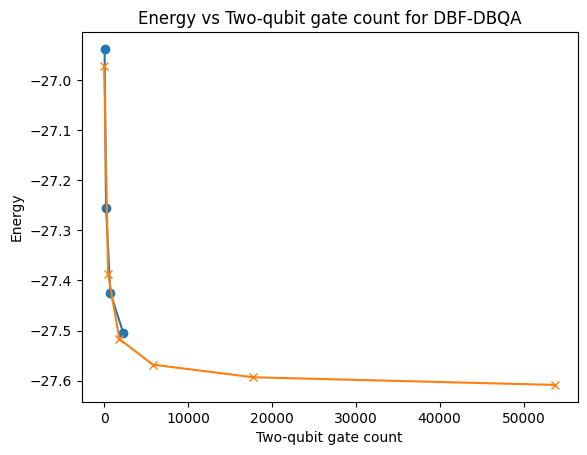

In [ ]:
plt.figure()
plt.plot(dbf_dbqa_two_qubit_counts, dbf_dbqa_energies, marker='o')
plt.plot(db_qite_cz_counts, db_qite_energies, marker='x', label='DB-QITE')
plt.xlabel('Two-qubit gate count')
plt.ylabel('Energy')
plt.title('Energy vs Two-qubit gate count for DBF-DBQA')
plt.show()